In [3]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("MPS available:", torch.backends.mps.is_available())

PyTorch: 2.13.0
Torchvision: 0.28.0
MPS available: True


In [5]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [8]:
from pathlib import Path

home = Path.home()

print("Home:", home)
print("\nDesktop contents:")

for item in (home / "Desktop").iterdir():
    print(item)

Home: /Users/sumanghosh

Desktop contents:
/Users/sumanghosh/Desktop/.DS_Store
/Users/sumanghosh/Desktop/.localized
/Users/sumanghosh/Desktop/Desktop
/Users/sumanghosh/Desktop/.ipynb_checkpoints
/Users/sumanghosh/Desktop/INTELLIJ
/Users/sumanghosh/Desktop/YouTube(brave).crwebloc


In [9]:
from pathlib import Path

desktop = Path.home() / "Desktop"

print("Semester folders:")

for item in desktop.rglob("cifar-10-batches-py"):
    print(item)

Semester folders:
/Users/sumanghosh/Desktop/Desktop/Semester/Sem 7/Project/Project/cifar-10-batches-py


In [10]:
from pathlib import Path

cifar_path = Path(
    "~/Desktop/Desktop/Semester/Sem 7/Project/Project/cifar-10-batches-py"
).expanduser()

print("CIFAR-10 path:", cifar_path)
print("Exists:", cifar_path.exists())

CIFAR-10 path: /Users/sumanghosh/Desktop/Desktop/Semester/Sem 7/Project/Project/cifar-10-batches-py
Exists: True


In [11]:
print([file.name for file in cifar_path.iterdir()])

['data_batch_1', 'readme.html', 'batches.meta', 'data_batch_2', 'data_batch_5', 'test_batch', 'data_batch_4', 'data_batch_3']


In [12]:
import torchvision

train_dataset = torchvision.datasets.CIFAR10(
    root=str(cifar_path.parent),
    train=True,
    download=False
)

test_dataset = torchvision.datasets.CIFAR10(
    root=str(cifar_path.parent),
    train=False,
    download=False
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

Training images: 50000
Test images: 10000


In [13]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

In [14]:
train_dataset = torchvision.datasets.CIFAR10(
    root=str(cifar_path.parent),
    train=True,
    download=False,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=str(cifar_path.parent),
    train=False,
    download=False,
    transform=test_transform
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

Training images: 50000
Test images: 10000


In [15]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Test batches:", len(test_loader))

Training batches: 391
Test batches: 79


In [16]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)

Images shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])
Image dtype: torch.float32


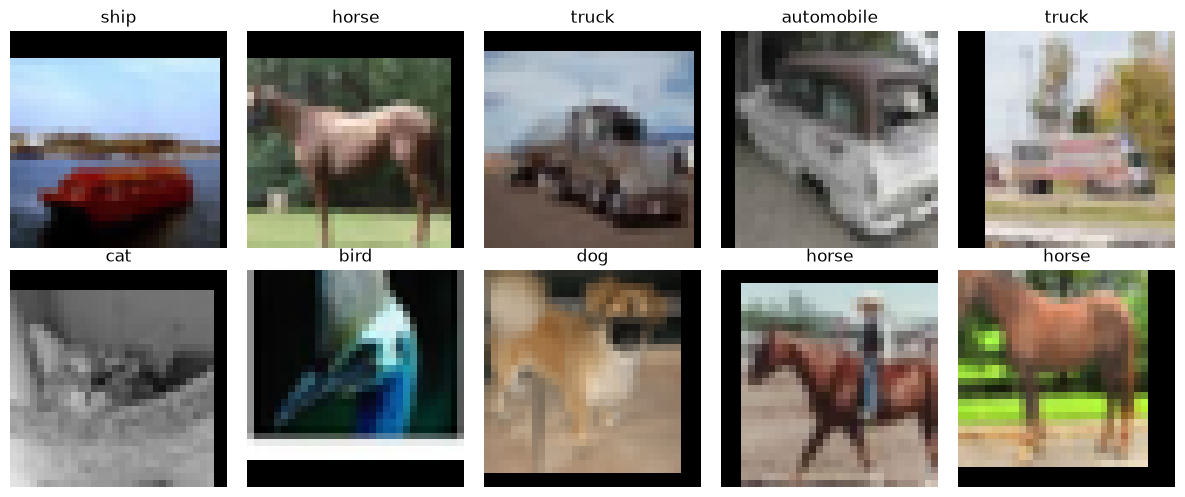

In [17]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0)
    
    ax.imshow(image)
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [19]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # First 3x3 convolution
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        # Second 3x3 convolution
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.stride = stride
        self.in_channels = in_channels
        self.out_channels = out_channels

    def shortcut(self, x):
        # No change in size/channels
        if self.stride == 1 and self.in_channels == self.out_channels:
            return x

        # Paper's CIFAR-10 identity shortcut:
        # downsample spatial dimensions when needed
        out = x[:, :, ::2, ::2]

        # Add zero-filled channels when channel number increases
        channel_difference = self.out_channels - self.in_channels

        if channel_difference > 0:
            out = F.pad(
                out,
                (0, 0, 0, 0, 0, channel_difference)
            )

        return out

    def forward(self, x):

        # Residual path
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Shortcut path
        shortcut = self.shortcut(x)

        # Residual + shortcut
        out = out + shortcut

        # ReLU after addition
        out = F.relu(out)

        return out

In [20]:
block = BasicBlock(
    in_channels=16,
    out_channels=16,
    stride=1
)

x = torch.randn(4, 16, 32, 32)

y = block(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : torch.Size([4, 16, 32, 32])
Output shape: torch.Size([4, 16, 32, 32])


In [22]:
class ResNet20(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        # Initial convolution
        self.conv1 = nn.Conv2d(
            3,
            16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(16)

        # 32 x 32, 16 channels
        self.layer1 = self.make_layer(
            16,
            16,
            num_blocks=3,
            stride=1
        )

        # 16 x 16, 32 channels
        self.layer2 = self.make_layer(
            16,
            32,
            num_blocks=3,
            stride=2
        )

        # 8 x 8, 64 channels
        self.layer3 = self.make_layer(
            32,
            64,
            num_blocks=3,
            stride=2
        )

        # Global Average Pooling
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # 10-class classifier
        self.fc = nn.Linear(64, num_classes)

    def make_layer(
        self,
        in_channels,
        out_channels,
        num_blocks,
        stride
    ):

        layers = []

        # First block may perform downsampling
        layers.append(
            BasicBlock(
                in_channels,
                out_channels,
                stride
            )
        )

        # Remaining blocks
        for _ in range(1, num_blocks):
            layers.append(
                BasicBlock(
                    out_channels,
                    out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):

        # Initial convolution
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        # Global average pooling
        x = self.avg_pool(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Classifier
        x = self.fc(x)

        return x

In [27]:
print("Device:", device)

Device: mps


In [28]:
model = ResNet20(num_classes=10)

model = model.to(device)

print("Model device:", next(model.parameters()).device)

Model device: mps:0


In [29]:
test_input = torch.randn(4, 3, 32, 32).to(device)

test_output = model(test_input)

print("Input shape :", test_input.shape)
print("Output shape:", test_output.shape)

Input shape : torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])


In [30]:
criterion = nn.CrossEntropyLoss()

In [31]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=0.0001
)

In [32]:
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[40, 60],
    gamma=0.1
)

In [33]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy

In [34]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy

In [35]:
num_epochs = 80

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

best_accuracy = 0.0

In [36]:
for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    if test_accuracy > best_accuracy:

        best_accuracy = test_accuracy

        torch.save(
            model.state_dict(),
            "best_resnet20_cifar10.pth"
        )

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.2f}%"
    )

Epoch [01/80] Train Loss: 1.6956 | Train Acc: 36.91% | Test Loss: 1.4747 | Test Acc: 46.76%
Epoch [02/80] Train Loss: 1.2106 | Train Acc: 56.18% | Test Loss: 1.1540 | Test Acc: 58.68%
Epoch [03/80] Train Loss: 0.9445 | Train Acc: 66.38% | Test Loss: 0.9340 | Test Acc: 68.27%
Epoch [04/80] Train Loss: 0.7798 | Train Acc: 72.81% | Test Loss: 0.7570 | Test Acc: 73.90%
Epoch [05/80] Train Loss: 0.6863 | Train Acc: 76.19% | Test Loss: 0.7137 | Test Acc: 75.51%
Epoch [06/80] Train Loss: 0.6271 | Train Acc: 78.36% | Test Loss: 0.7280 | Test Acc: 75.54%
Epoch [07/80] Train Loss: 0.5761 | Train Acc: 80.08% | Test Loss: 0.7513 | Test Acc: 74.62%
Epoch [08/80] Train Loss: 0.5463 | Train Acc: 81.01% | Test Loss: 0.6323 | Test Acc: 79.10%
Epoch [09/80] Train Loss: 0.5124 | Train Acc: 82.05% | Test Loss: 0.9633 | Test Acc: 71.68%
Epoch [10/80] Train Loss: 0.4909 | Train Acc: 82.98% | Test Loss: 0.6085 | Test Acc: 79.75%
Epoch [11/80] Train Loss: 0.4625 | Train Acc: 84.03% | Test Loss: 0.6759 | Test 

In [37]:
model.load_state_dict(
    torch.load(
        "best_resnet20_cifar10.pth",
        map_location=device
    )
)

model = model.to(device)

print("Best ResNet-20 model loaded.")
print("Best test accuracy:", best_accuracy)

Best ResNet-20 model loaded.
Best test accuracy: 90.92


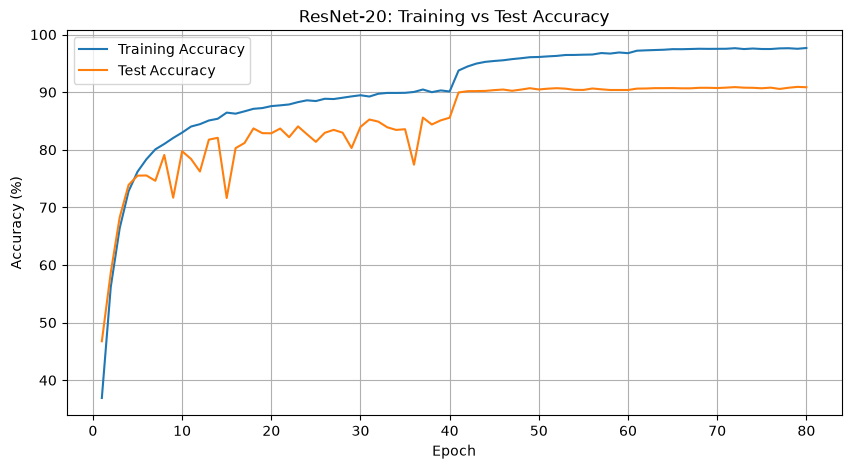

In [38]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    test_accuracies,
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-20: Training vs Test Accuracy")
plt.legend()
plt.grid(True)

plt.show()

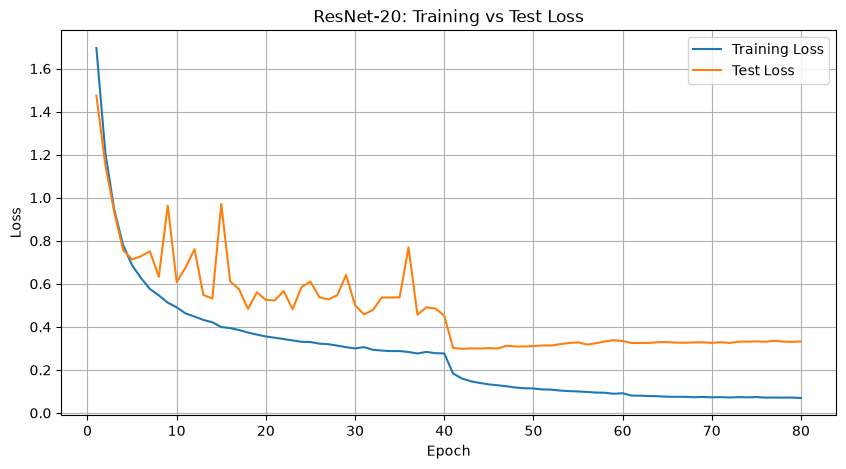

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    test_losses,
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-20: Training vs Test Loss")
plt.legend()
plt.grid(True)

plt.show()

In [40]:
final_test_loss, final_test_accuracy = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_accuracy:.2f}%")
print(f"Test Error: {100 - final_test_accuracy:.2f}%")

Test Loss: 0.3307
Test Accuracy: 90.92%
Test Error: 9.08%


In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[929   2  17  10   7   0   5   5  19   6]
 [  6 953   0   1   1   1   2   1   7  28]
 [ 16   0 875  27  27  15  23  13   2   2]
 [ 10   1  27 830  14  68  24  17   4   5]
 [  4   1  25  21 904  14  11  17   2   1]
 [  4   1  10  88  22 850   7  17   1   0]
 [  2   1  18  32   8   9 925   2   2   1]
 [  5   0  12  14  19  20   1 926   1   2]
 [ 29   6   2   6   1   0   1   1 947   7]
 [  9  23   2   5   1   0   0   0   7 953]]


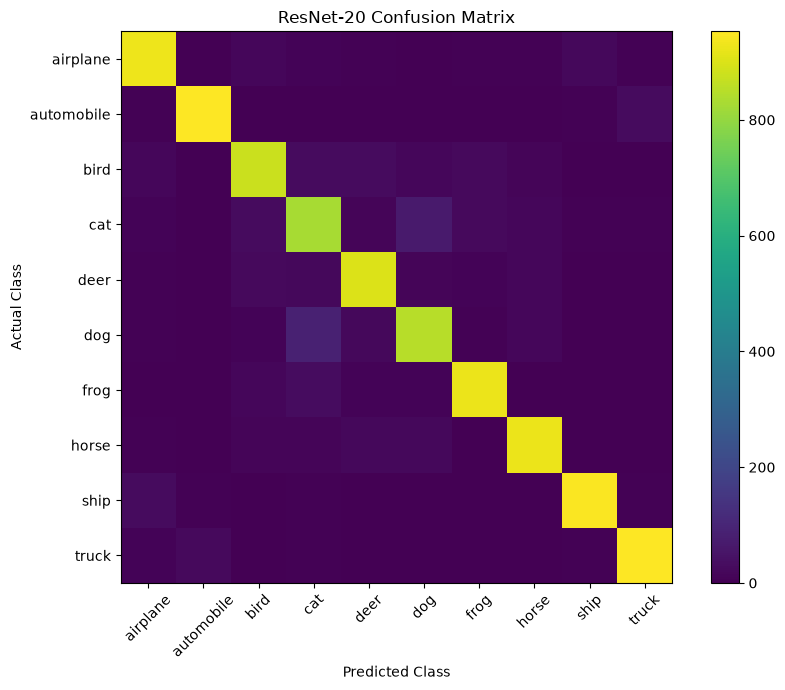

In [42]:
plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.colorbar()

classes = test_dataset.classes

plt.xticks(
    range(10),
    classes,
    rotation=45
)

plt.yticks(
    range(10),
    classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("ResNet-20 Confusion Matrix")

plt.tight_layout()
plt.show()

In [43]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.9162    0.9290    0.9225      1000
  automobile     0.9646    0.9530    0.9588      1000
        bird     0.8856    0.8750    0.8803      1000
         cat     0.8027    0.8300    0.8161      1000
        deer     0.9004    0.9040    0.9022      1000
         dog     0.8700    0.8500    0.8599      1000
        frog     0.9259    0.9250    0.9255      1000
       horse     0.9269    0.9260    0.9265      1000
        ship     0.9546    0.9470    0.9508      1000
       truck     0.9483    0.9530    0.9506      1000

    accuracy                         0.9092     10000
   macro avg     0.9095    0.9092    0.9093     10000
weighted avg     0.9095    0.9092    0.9093     10000

